# Car Price Prediction with Machine Learning

## Objective

The objective of this project is to build machine learning regression models
that predict used-car selling prices based on vehicle characteristics such
as brand, model, vehicle age, mileage, engine, maximum power, fuel type,
transmission, seller type, kilometers driven, and number of seats.

Two regression models are trained and compared:

- Linear Regression
- Random Forest Regressor

The models are evaluated using MAE, RMSE, and R² score.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("cardekho_dataset.csv")

In [4]:
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.6+ MB


In [6]:
df.duplicated().sum()

0

In [7]:
print("Brands:")
print(df['brand'].unique())

print("\nFuel Types:")
print(df['fuel_type'].unique())

print("\nTransmission Types:")
print(df['transmission_type'].unique())

print("\nSeller Types:")
print(df['seller_type'].unique())

Brands:
['Maruti' 'Hyundai' 'Ford' 'Renault' 'Mini' 'Mercedes-Benz' 'Toyota'
 'Volkswagen' 'Honda' 'Mahindra' 'Datsun' 'Tata' 'Kia' 'BMW' 'Audi'
 'Land Rover' 'Jaguar' 'MG' 'Isuzu' 'Porsche' 'Skoda' 'Volvo' 'Lexus'
 'Jeep' 'Maserati' 'Bentley' 'Nissan' 'ISUZU' 'Ferrari' 'Mercedes-AMG'
 'Rolls-Royce' 'Force']

Fuel Types:
['Petrol' 'Diesel' 'CNG' 'LPG' 'Electric']

Transmission Types:
['Manual' 'Automatic']

Seller Types:
['Individual' 'Dealer' 'Trustmark Dealer']


In [8]:
df['brand'] = df['brand'].str.title()

print(df['brand'].unique())

['Maruti' 'Hyundai' 'Ford' 'Renault' 'Mini' 'Mercedes-Benz' 'Toyota'
 'Volkswagen' 'Honda' 'Mahindra' 'Datsun' 'Tata' 'Kia' 'Bmw' 'Audi'
 'Land Rover' 'Jaguar' 'Mg' 'Isuzu' 'Porsche' 'Skoda' 'Volvo' 'Lexus'
 'Jeep' 'Maserati' 'Bentley' 'Nissan' 'Ferrari' 'Mercedes-Amg'
 'Rolls-Royce' 'Force']


In [9]:
df['brand'] = df['brand'].replace({
    'Bmw': 'BMW',
    'Mg': 'MG',
    'Mercedes-Amg': 'Mercedes-AMG'
})

print(df['brand'].unique())

['Maruti' 'Hyundai' 'Ford' 'Renault' 'Mini' 'Mercedes-Benz' 'Toyota'
 'Volkswagen' 'Honda' 'Mahindra' 'Datsun' 'Tata' 'Kia' 'BMW' 'Audi'
 'Land Rover' 'Jaguar' 'MG' 'Isuzu' 'Porsche' 'Skoda' 'Volvo' 'Lexus'
 'Jeep' 'Maserati' 'Bentley' 'Nissan' 'Ferrari' 'Mercedes-AMG'
 'Rolls-Royce' 'Force']


In [10]:
numeric_columns = [
    'vehicle_age',
    'km_driven',
    'mileage',
    'engine',
    'max_power',
    'seats',
    'selling_price'
]

df[numeric_columns].describe()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


In [11]:
print("Cars with 0 seats:")
display(df[df['seats'] == 0])

print("\nCars with unusually high km_driven:")
display(df[df['km_driven'] > 500000])

print("\nCars with very high selling_price:")
display(df[df['selling_price'] > 10000000])

Cars with 0 seats:


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
3217,4098,Honda City,Honda,City,18,40000,Individual,Petrol,Manual,13.00,1493,100.00,0,115000
12619,15992,Nissan Kicks,Nissan,Kicks,2,10000,Individual,Diesel,Manual,19.39,1461,108.49,0,1154000



Cars with unusually high km_driven:


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
2731,3477,Ford Figo,Ford,Figo,10,570000,Dealer,Petrol,Manual,15.60,1196,70.00,5,200000
4532,5754,Renault Duster,Renault,Duster,4,850000,Dealer,Diesel,Manual,19.87,1461,83.80,5,850000
6712,8565,Volkswagen Vento,Volkswagen,Vento,9,830000,Dealer,Diesel,Manual,20.54,1598,103.60,5,380000
7323,9367,Ford Ecosport,Ford,Ecosport,6,720000,Dealer,Diesel,Manual,22.70,1498,89.84,5,675000
7534,9636,Toyota Fortuner,Toyota,Fortuner,2,590000,Dealer,Diesel,Manual,14.24,2755,174.50,7,2850000
8772,11291,Toyota Innova,Toyota,Innova,6,950000,Dealer,Diesel,Manual,12.99,2494,100.60,7,950000
9170,11792,Skoda Rapid,Skoda,Rapid,5,675000,Dealer,Diesel,Automatic,21.66,1498,103.52,5,675000
10384,13242,Honda Jazz,Honda,Jazz,4,525000,Dealer,Petrol,Manual,18.70,1199,88.70,5,525000
10838,13790,Hyundai Creta,Hyundai,Creta,6,825000,Dealer,Diesel,Manual,19.67,1582,126.20,5,825000
11615,14746,Volkswagen Polo,Volkswagen,Polo,5,820000,Dealer,Petrol,Automatic,17.21,1197,103.50,5,695000



Cars with very high selling_price:


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
1172,1508,Bentley Continental,Bentley,Continental,9,9000,Dealer,Petrol,Automatic,9.50,5998,626.00,4,14500000
1888,2428,Mercedes-Benz S-Class,Mercedes-Benz,S-Class,5,41000,Dealer,Petrol,Automatic,7.81,5461,362.90,5,11000000
3799,4845,Ferrari GTC4Lusso,Ferrari,GTC4Lusso,2,3800,Dealer,Petrol,Automatic,4.00,3855,601.00,4,39500000
9364,12023,Porsche Cayenne,Porsche,Cayenne,4,24000,Dealer,Petrol,Automatic,12.50,3604,440.00,5,11100000
9722,12456,Mercedes-Benz S-Class,Mercedes-Benz,S-Class,3,4000,Dealer,Petrol,Automatic,7.81,4663,459.00,4,13000000
10969,13944,Rolls-Royce Ghost,Rolls-Royce,Ghost,4,5000,Individual,Petrol,Automatic,10.20,6592,563.00,4,24200000
10989,13966,Mercedes-Benz S-Class,Mercedes-Benz,S-Class,2,18000,Dealer,Petrol,Automatic,7.81,2996,362.07,5,11000000


In [12]:
df = df[df['seats'] > 0].copy()

print("Dataset shape after removing invalid seat values:", df.shape)
print("Rows with 0 seats:", (df['seats'] == 0).sum())

Dataset shape after removing invalid seat values: (15409, 14)
Rows with 0 seats: 0


In [13]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Rows: 15409
Columns: 14
Missing values: 0
Duplicate rows: 0


### Feature Engineering

The selected CarDekho dataset already provides `vehicle_age` and `brand` as
separate features. Therefore, additional extraction of car age from a year
column or brand from the car name was not required.

The provided `vehicle_age` and `brand` features were cleaned and used directly
in the model.

## Exploratory Data Analysis

### Distribution of Selling Prices

The distribution of selling prices helps us understand the overall price range of the used cars in the dataset and identify whether the prices are concentrated in a particular range or affected by extreme values.

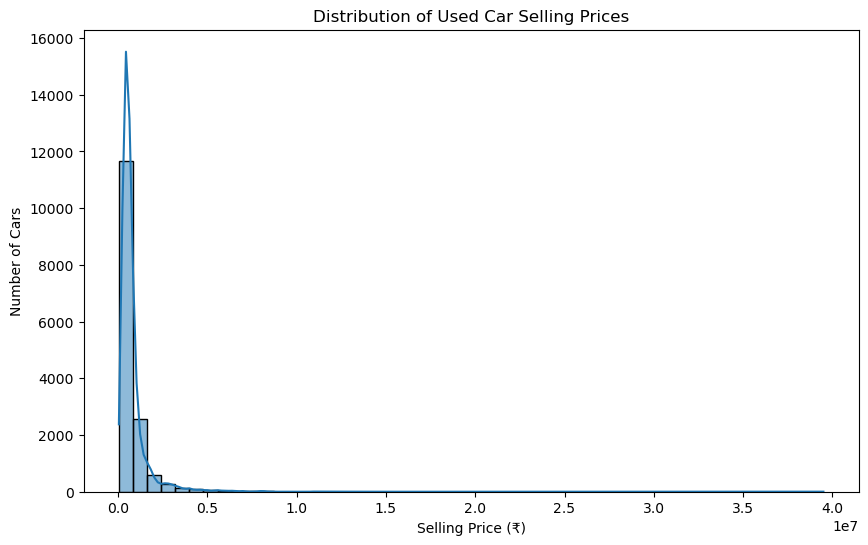

In [16]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df['selling_price'],
    bins=50,
    kde=True
)

plt.title('Distribution of Used Car Selling Prices')
plt.xlabel('Selling Price (₹)')
plt.ylabel('Number of Cars')
plt.show()

### Observation

The selling-price distribution is strongly right-skewed. Most used cars are concentrated in the lower price range, while a small number of luxury vehicles have substantially higher selling prices. These high-value cars create a long right tail in the distribution.

### Selling Price by Fuel Type

Comparing selling prices across fuel types helps identify differences in the price distribution of petrol, diesel, CNG, LPG, and electric vehicles.

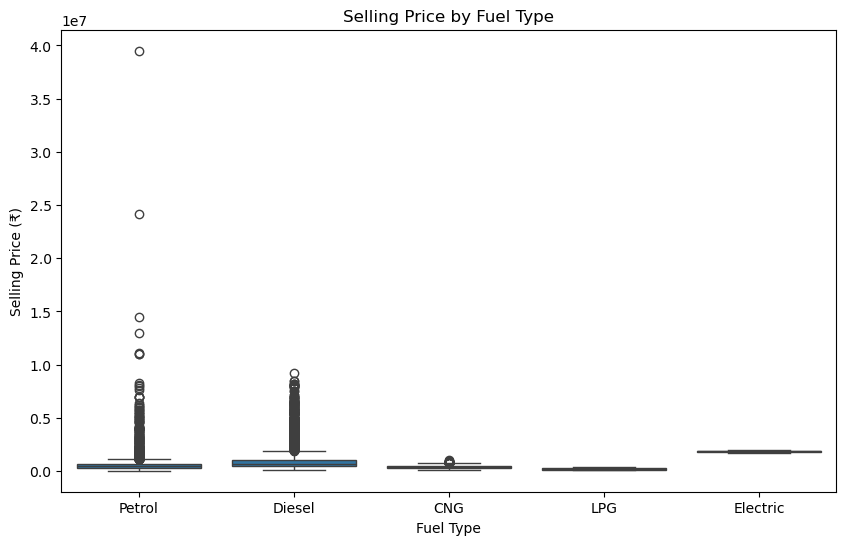

In [19]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='fuel_type',
    y='selling_price'
)

plt.title('Selling Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Selling Price (₹)')
plt.show()

### Observation

The box plot shows noticeable differences in selling-price distributions across fuel types. Petrol and diesel vehicles have wider price distributions and several high-price outliers, while CNG and LPG vehicles have narrower distributions. Electric vehicles appear to have a higher price range in this dataset, although the relatively smaller number of observations should be considered when interpreting this result.

### Selling Price vs Vehicle Age

The relationship between vehicle age and selling price can help us understand how depreciation affects the value of used cars.

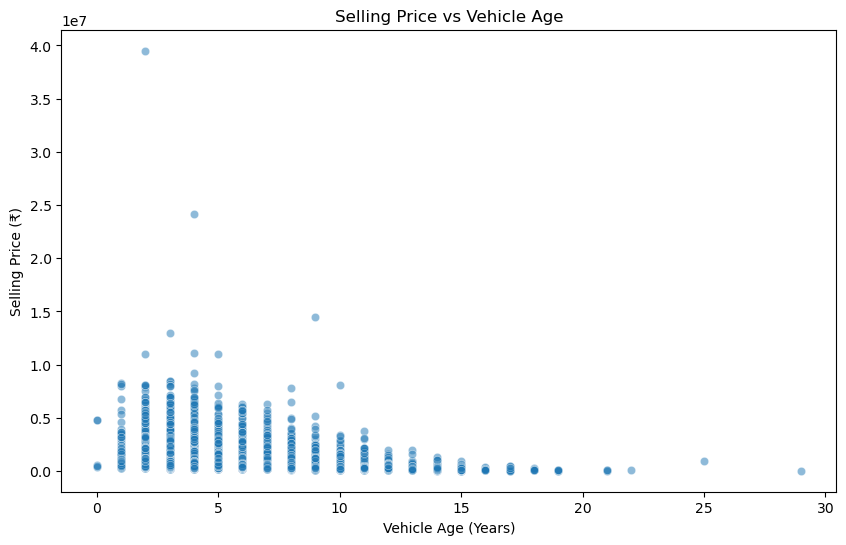

In [22]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='vehicle_age',
    y='selling_price',
    alpha=0.5
)

plt.title('Selling Price vs Vehicle Age')
plt.xlabel('Vehicle Age (Years)')
plt.ylabel('Selling Price (₹)')
plt.show()

### Observation

The scatter plot shows a general negative relationship between vehicle age and selling price. Newer vehicles tend to have higher selling prices, while older vehicles generally have lower prices. However, considerable variation exists at similar vehicle ages, indicating that other factors such as brand, model, mileage, engine, fuel type, and transmission also influence selling price. A few high-price outliers are visible among newer vehicles.

In [24]:
df = df.drop(columns=['Unnamed: 0'])

print("Dataset shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

Dataset shape: (15409, 13)
Columns:
['car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']


### Feature Correlation Heatmap

A correlation heatmap helps identify the strength and direction of relationships between numerical features and selling price. This can help us understand which numerical variables may be useful for predicting car prices.

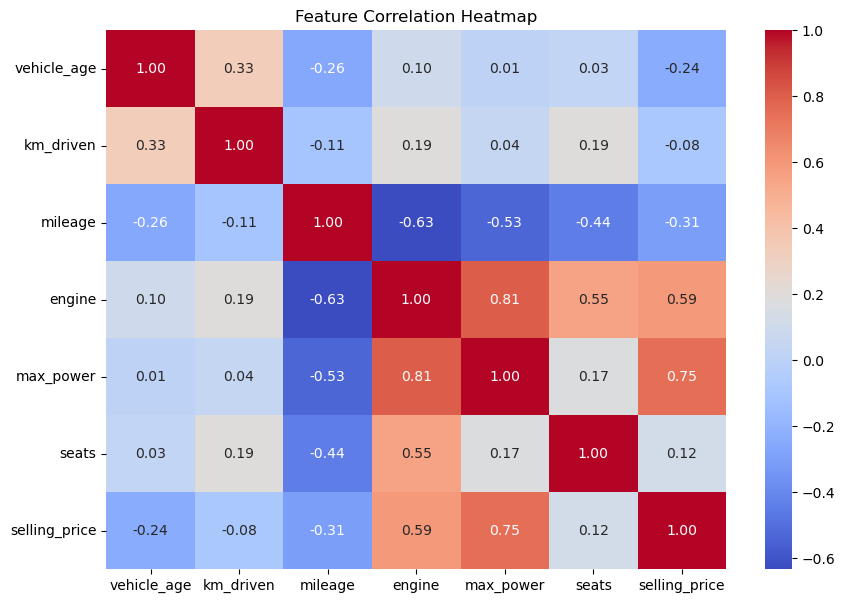

In [26]:
numeric_features = [
    'vehicle_age',
    'km_driven',
    'mileage',
    'engine',
    'max_power',
    'seats',
    'selling_price'
]

correlation_matrix = df[numeric_features].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Feature Correlation Heatmap')
plt.show()

### Observation

The correlation analysis shows that max_power has the strongest positive correlation with selling price (0.75), followed by engine size (0.59). Mileage and vehicle age have negative correlations with selling price (-0.31 and -0.24 respectively), suggesting that older vehicles and vehicles with higher mileage generally tend to have lower selling prices.

The correlation between km_driven and selling_price is weakly negative (-0.08), while seats has a weak positive correlation (0.12). A strong positive correlation is also observed between engine and max_power (0.81), indicating that these two features are closely related.

## Machine Learning Preparation

The target variable is `selling_price`. The remaining relevant numerical and categorical variables will be used as predictors. The `car_name` column is excluded because brand and model already represent the vehicle identity while avoiding a very high-cardinality categorical feature.

### Feature Engineering

The selected CarDekho dataset already provides `vehicle_age` and `brand` as
separate features. Therefore, additional extraction of car age from a year
column or brand from the car name was not required.

The provided `vehicle_age` and `brand` features were cleaned and used directly
in the model.

In [29]:
X = df.drop(columns=['selling_price', 'car_name'])
y = df['selling_price']

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeatures:")
print(X.columns.tolist())

Feature shape: (15409, 11)
Target shape: (15409,)

Features:
['brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats']


### Feature Types

The dataset contains both numerical and categorical predictors. Numerical features can be used directly by the regression models, while categorical features must be encoded into numerical values before model training.

In [31]:
categorical_features = [
    'brand',
    'model',
    'seller_type',
    'fuel_type',
    'transmission_type'
]

numerical_features = [
    'vehicle_age',
    'km_driven',
    'mileage',
    'engine',
    'max_power',
    'seats'
]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']

Numerical features:
['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']


### Train-Test Split

The dataset is divided into training and testing sets. The training set is used to learn the regression models, while the testing set is reserved for evaluating how well the models perform on unseen data.

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (12327, 11)
Testing features: (3082, 11)
Training target: (12327,)
Testing target: (3082,)


### Categorical Encoding

Categorical variables cannot be directly used by most machine learning regression algorithms. One-Hot Encoding converts each categorical value into a numerical binary feature. The encoder is fitted only on the training data to avoid data leakage, and unseen categories in the test data are ignored.

In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('numerical', 'passthrough', numerical_features)
    ]
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print("Encoded training shape:", X_train_encoded.shape)
print("Encoded testing shape:", X_test_encoded.shape)

Encoded training shape: (12327, 166)
Encoded testing shape: (3082, 166)


## Model Training

### 1. Linear Regression

Linear Regression is used as a baseline regression model. It attempts to model the relationship between the input features and selling price using a linear combination of the predictors.

In [37]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train_encoded, y_train)

linear_predictions = linear_model.predict(X_test_encoded)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


### Linear Regression Evaluation

The Linear Regression model is evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² score. MAE and RMSE measure prediction error, while R² indicates how much of the variation in selling price is explained by the model.

In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_r2 = r2_score(y_test, linear_predictions)

print(f"Linear Regression MAE: ₹{linear_mae:,.2f}")
print(f"Linear Regression RMSE: ₹{linear_rmse:,.2f}")
print(f"Linear Regression R² Score: {linear_r2:.4f}")

Linear Regression MAE: ₹255,245.93
Linear Regression RMSE: ₹447,947.93
Linear Regression R² Score: 0.6732


### 2. Random Forest Regressor

Random Forest Regressor is an ensemble machine learning model that combines multiple decision trees to make predictions. It can capture nonlinear relationships between car features and selling price, making it suitable for this dataset.

In [41]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train_encoded, y_train)

random_forest_predictions = random_forest_model.predict(X_test_encoded)

print("Random Forest Regressor model trained successfully.")

Random Forest Regressor model trained successfully.


### Random Forest Evaluation

The Random Forest Regressor is evaluated using MAE, RMSE, and R² score. These metrics allow us to compare its predictive performance with the Linear Regression baseline.

In [43]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

random_forest_mae = mean_absolute_error(
    y_test,
    random_forest_predictions
)

random_forest_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        random_forest_predictions
    )
)

random_forest_r2 = r2_score(
    y_test,
    random_forest_predictions
)

print(f"Random Forest MAE: ₹{random_forest_mae:,.2f}")
print(f"Random Forest RMSE: ₹{random_forest_rmse:,.2f}")
print(f"Random Forest R² Score: {random_forest_r2:.4f}")

Random Forest MAE: ₹93,220.77
Random Forest RMSE: ₹181,674.61
Random Forest R² Score: 0.9462


## Model Comparison

The performance of Linear Regression and Random Forest Regressor is compared using MAE, RMSE, and R² score. Lower MAE and RMSE indicate smaller prediction errors, while a higher R² score indicates better explanatory and predictive performance.

In [45]:
model_comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest Regressor'
    ],
    'MAE': [
        linear_mae,
        random_forest_mae
    ],
    'RMSE': [
        linear_rmse,
        random_forest_rmse
    ],
    'R² Score': [
        linear_r2,
        random_forest_r2
    ]
})

model_comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,255245.926632,447947.925234,0.673167
1,Random Forest Regressor,93220.767750,181674.614720,0.946240


### Observation

The Random Forest Regressor significantly outperforms Linear Regression across all three evaluation metrics. It has substantially lower MAE and RMSE and a considerably higher R² score of 0.9462 compared with 0.6732 for Linear Regression.

Therefore, Random Forest Regressor is selected as the best-performing model for predicting used-car selling prices in this project.

## Feature Importance

Feature importance shows how much each input feature contributes to the predictions made by the Random Forest model. Since categorical variables were One-Hot Encoded, the importance values are available for each encoded feature.

In [48]:
feature_names = preprocessor.get_feature_names_out()

feature_importance = pd.Series(
    random_forest_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

feature_importance.head(15)

numerical__max_power                0.650414
numerical__vehicle_age              0.125957
numerical__km_driven                0.055479
numerical__mileage                  0.040659
categorical__brand_Ferrari          0.027770
numerical__engine                   0.022918
categorical__model_GTC4Lusso        0.019197
categorical__brand_Rolls-Royce      0.004732
categorical__brand_Land Rover       0.004571
categorical__model_Rover            0.004153
categorical__model_Ghost            0.004088
categorical__brand_Mercedes-Benz    0.003805
numerical__seats                    0.002314
categorical__model_Continental      0.001652
categorical__seller_type_Dealer     0.001516
dtype: float64

### Top 15 Feature Importances

The following chart shows the 15 most important features used by the Random Forest Regressor. Higher importance values indicate a greater contribution to the model's predictions.

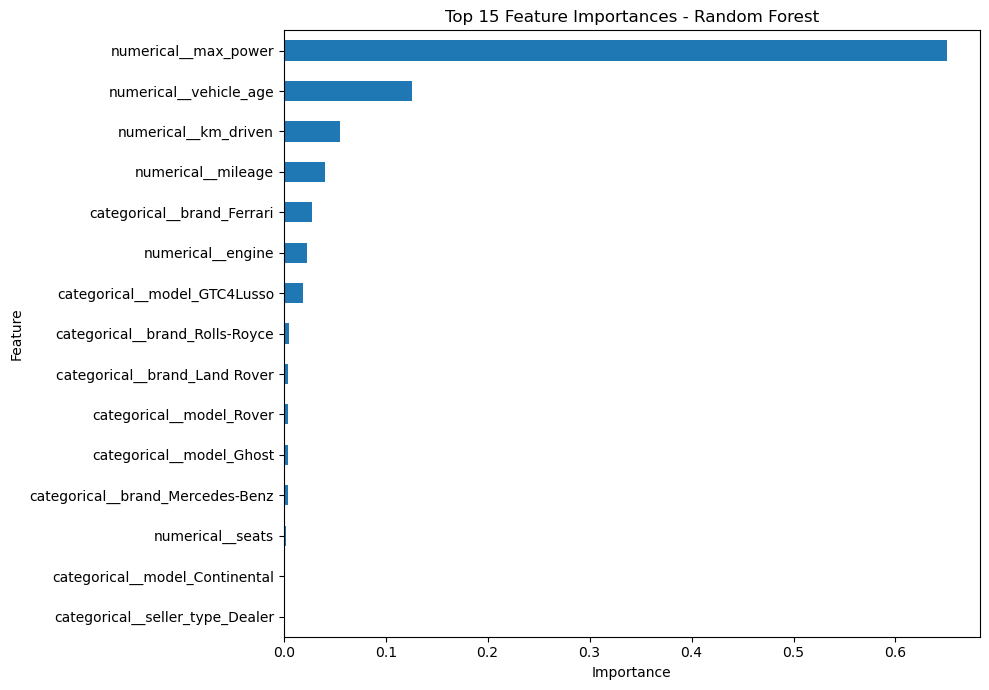

In [50]:
top_features = feature_importance.head(15).sort_values(ascending=True)

plt.figure(figsize=(10, 7))

top_features.plot(kind='barh')

plt.title('Top 15 Feature Importances - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

### Observation

The feature-importance analysis shows that `max_power` is the most influential feature in the Random Forest model, with an importance of approximately 0.65. Vehicle age is the second most important feature, followed by kilometers driven and mileage.

Several brand and model categories, particularly luxury-car categories such as Ferrari, Rolls-Royce, and Land Rover, also contribute to the model's predictions. This indicates that both numerical vehicle characteristics and categorical information about the car influence used-car selling prices.

### Actual vs Predicted Selling Prices

This scatter plot compares the actual selling prices from the test dataset with the prices predicted by the Random Forest Regressor. Points closer to the diagonal reference line indicate more accurate predictions.

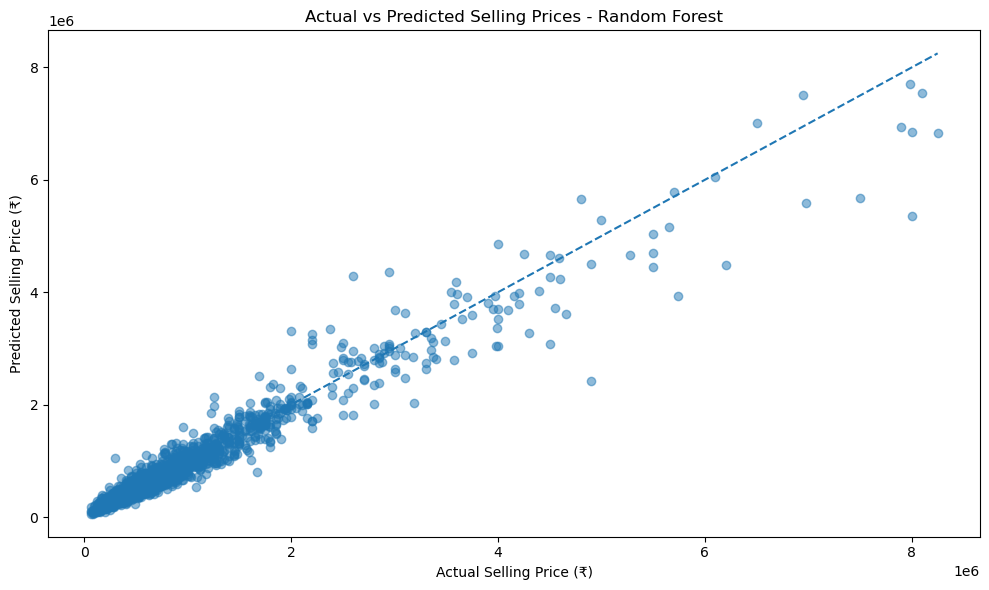

In [53]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    random_forest_predictions,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.title('Actual vs Predicted Selling Prices - Random Forest')
plt.xlabel('Actual Selling Price (₹)')
plt.ylabel('Predicted Selling Price (₹)')

plt.tight_layout()
plt.show()

### Observation

The actual vs predicted plot shows that most predictions are reasonably close to the diagonal reference line, indicating good agreement between the actual and predicted selling prices. The predictions are particularly concentrated around the reference line for lower and mid-range priced vehicles.

Greater deviations are visible for some high-priced vehicles, suggesting that the model has more difficulty predicting prices at the upper end of the market. Overall, the plot supports the strong predictive performance indicated by the Random Forest R² score of 0.9462.

# Final Results and Conclusion

## Model Performance

Two regression models were trained and evaluated using MAE, RMSE, and R² score.

| Model | MAE | RMSE | R² Score |
|---|---:|---:|---:|
| Linear Regression | ₹255,245.93 | ₹447,947.93 | 0.6732 |
| Random Forest Regressor | ₹93,220.77 | ₹181,674.61 | 0.9462 |

### Best Model

The **Random Forest Regressor** is the best-performing model because it achieved the lowest MAE and RMSE and the highest R² score.

### Key Findings

- `max_power` is the most important feature in the Random Forest model.
- Vehicle age is the second most influential feature.
- Kilometers driven and mileage also contribute to price prediction.
- Brand and model categories provide additional predictive information.
- Random Forest captures nonlinear relationships in the data more effectively than Linear Regression.